# AI-Based System for Residential Energy Efficiency Optimization

## Project Overview

This project develops and evaluates an AI-based residential energy-efficiency advisor using GPT-2 with LoRA fine-tuning. The Appliances Energy Prediction dataset is used to represent realistic household energy and environmental conditions.

The selected features include appliance energy consumption, indoor temperature, indoor humidity, outdoor temperature, and outdoor humidity. Numerical measurements are converted into structured prompt-response examples that guide the model to generate an assessment, practical recommendations, and limitations.

## Technical Approach

The project establishes a GPT-2 baseline before fine-tuning and then applies LoRA to train adapter parameters rather than the entire model. The workflow includes tokenization, training, loss evaluation, response comparison, hallucination-risk testing, model saving, and reload verification.

The same evaluation scenarios are applied before and after fine-tuning to support a controlled comparison. Additional tests examine whether the model produces unsupported exact or causal claims based on the available sensor data.

The generated responses are treated as advisory guidance rather than validated engineering recommendations.

## 1. Import Libraries

In [1]:
import os
import random
import platform
from pathlib import Path
import html
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import shutil

from IPython.display import display, HTML, Markdown

from datasets import Dataset
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from sklearn.model_selection import train_test_split
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    default_data_collator,
    Trainer,
    TrainingArguments,
    set_seed,
)

import warnings

warnings.filterwarnings(
    "ignore",
    message=".*fan_in_fan_out.*"
)

RANDOM_SEED = 42

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
set_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

## 2. Set Project Paths and Configuration

In [2]:
PROJECT_TITLE = "AI-Based System for Residential Energy Efficiency Optimization"

MODEL_NAME = "gpt2"

CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

DATA_FILE = DATA_DIR / "KAG_energydata_complete.csv"
CHECKPOINT_FOLDER = MODELS_DIR / "checkpoints"
FINAL_ADAPTER_FOLDER = MODELS_DIR / "gpt2_energy_lora_adapter"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

if CHECKPOINT_FOLDER.exists():
    shutil.rmtree(CHECKPOINT_FOLDER)

CHECKPOINT_FOLDER.mkdir(parents=True, exist_ok=True)
FINAL_ADAPTER_FOLDER.mkdir(parents=True, exist_ok=True)

SELECTED_COLUMNS = [
    "Appliances",
    "T1",
    "RH_1",
    "T_out",
    "RH_out"
]

VALIDATION_SIZE = 0.10
MAX_LENGTH = 384
NUM_TRAIN_EPOCHS = 3

print("Execution setup completed.\n")

print(
    f"Device          : "
    f"{'GPU' if DEVICE.type == 'cuda' else 'CPU'}"
)

print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")

print(f"PyTorch version : {torch.__version__}")
print(f"Random seed     : {RANDOM_SEED}")

Execution setup completed.

Device          : CPU
CUDA available  : False
PyTorch version : 2.4.1+cpu
Random seed     : 42


## 3. Load the Dataset

In [3]:
if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_FILE.resolve()}\n"
        f"Place the dataset inside: {DATA_DIR.resolve()}"
    )

raw_df = pd.read_csv(DATA_FILE)

missing_columns = [
    column
    for column in SELECTED_COLUMNS
    if column not in raw_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

energy_df = raw_df[SELECTED_COLUMNS].copy()

for column in SELECTED_COLUMNS:
    energy_df[column] = pd.to_numeric(
        energy_df[column],
        errors="coerce"
    )

rows_before_cleaning = len(energy_df)

energy_df = (
    energy_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=SELECTED_COLUMNS)
    .copy()
)

valid_mask = (
    (energy_df["Appliances"] >= 0)
    & energy_df["T1"].between(-30, 60)
    & energy_df["RH_1"].between(0, 100)
    & energy_df["T_out"].between(-60, 60)
    & energy_df["RH_out"].between(0, 100)
)

energy_df = (
    energy_df.loc[valid_mask]
    .reset_index(drop=True)
)

print("Dataset preparation completed.\n")

print(f"Dataset           : {DATA_FILE.name}")
print(f"Original rows     : {rows_before_cleaning:,}")
print(f"Valid rows kept   : {len(energy_df):,}")
print(f"Rows removed      : {rows_before_cleaning - len(energy_df):,}")
print(f"Required columns  : {len(SELECTED_COLUMNS)}")

Dataset preparation completed.

Dataset           : KAG_energydata_complete.csv
Original rows     : 19,735
Valid rows kept   : 19,735
Rows removed      : 0
Required columns  : 5


## 4. Create Energy Categories

In [4]:
def classify_energy(value):
    if value < 100:
        return "low"
    elif value < 200:
        return "moderate"
    elif value < 300:
        return "high"
    else:
        return "very high"

def classify_temperature(value):
    if value < 18:
        return "cool"
    elif value <= 24:
        return "comfortable"
    else:
        return "warm"

def classify_humidity(value):
    if value < 30:
        return "dry"
    elif value <= 60:
        return "generally comfortable"
    else:
        return "humid"

print("Category classification functions created.")

Category classification functions created.


## 5. Balance the Training Data

In [5]:
energy_df["energy_category"] = (
    energy_df["Appliances"].apply(classify_energy)
)

energy_df["temperature_category"] = (
    energy_df["T1"].apply(classify_temperature)
)

energy_df["humidity_category"] = (
    energy_df["RH_1"].apply(classify_humidity)
)

energy_df["combined_category"] = (
    energy_df["energy_category"]
    + " | "
    + energy_df["temperature_category"]
    + " | "
    + energy_df["humidity_category"]
)

EXAMPLES_PER_COMBINATION = 30
balanced_parts = []

for combination, category_rows in energy_df.groupby(
    "combined_category"
):
    sampled_rows = category_rows.sample(
        n=EXAMPLES_PER_COMBINATION,
        replace=(
            len(category_rows)
            < EXAMPLES_PER_COMBINATION
        ),
        random_state=RANDOM_SEED
    )

    balanced_parts.append(
        sampled_rows
    )

balanced_energy_df = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .sample(
        frac=1,
        random_state=RANDOM_SEED
    )
    .reset_index(drop=True)
)

category_summary = (
    balanced_energy_df["energy_category"]
    .value_counts()
    .rename_axis("Energy Category")
    .reset_index(name="Records")
)

print("Balanced category sample created.\n")

print(
    f"Total balanced records : "
    f"{len(balanced_energy_df):,}"
)

print(
    f"Energy categories      : "
    f"{balanced_energy_df['energy_category'].nunique()}"
)

print("\nRecords by energy category:\n")

display(
    category_summary.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left"
        })
)

Balanced category sample created.

Total balanced records : 510
Energy categories      : 4

Records by energy category:



Energy Category,Records
high,150
very high,120
moderate,120
low,120


## 6. Build Energy-Efficiency Recommendations

In [6]:
def build_recommendations(row):
    recommendations = []

    if row["T1"] > 24:
        recommendations.append(
            "Review the thermostat schedule and reduce unnecessary cooling."
        )
    elif row["T1"] < 18:
        recommendations.append(
            "Check heating schedules, drafts, and insulation."
        )
    else:
        recommendations.append(
            "Maintain the current indoor temperature range."
        )

    if row["RH_1"] > 60:
        recommendations.append(
            "Use ventilation or dehumidification when appropriate."
        )
    elif row["RH_1"] < 30:
        recommendations.append(
            "Check whether heating is making the indoor air too dry."
        )
    else:
        recommendations.append(
            "Continue monitoring indoor humidity."
        )

    if row["T_out"] > row["T1"] + 5:
        recommendations.append(
            "Limit hot outdoor-air entry during the warmest hours."
        )
    elif row["T_out"] < row["T1"] - 5:
        recommendations.append(
            "Reduce drafts while heating is operating."
        )
    else:
        recommendations.append(
            "Use natural ventilation when outdoor conditions are suitable."
        )

    if row["Appliances"] >= 300:
        recommendations.append(
            "Review very high appliance use, standby loads, and operating schedules."
        )
    elif row["Appliances"] >= 200:
        recommendations.append(
            "Review high-load appliances and avoid unnecessary simultaneous operation."
        )
    elif row["Appliances"] >= 100:
        recommendations.append(
            "Monitor moderate appliance use and reduce unnecessary operating time."
        )
    else:
        recommendations.append(
            "Check for standby loads and unnecessary appliance runtime."
        )

    return recommendations


def build_limitations(row):
    limitations = []

    if row["Appliances"] >= 200:
        limitations.append(
            "The aggregate reading cannot identify which appliance caused the high use."
        )
    elif row["Appliances"] < 100:
        limitations.append(
            "A single low reading does not confirm sustained energy efficiency."
        )
    else:
        limitations.append(
            "Occupancy and appliance operating schedules are not available."
        )

    if row["T1"] > 24:
        limitations.append(
            "HVAC runtime, thermostat settings, and solar heat gain are unknown."
        )
    elif row["T1"] < 18:
        limitations.append(
            "Heating-system status, insulation quality, and draft locations are unknown."
        )
    elif row["RH_1"] > 60:
        limitations.append(
            "Ventilation rate and moisture-source data are unavailable."
        )
    elif row["RH_1"] < 30:
        limitations.append(
            "Heating runtime and indoor moisture-source data are unavailable."
        )
    else:
        limitations.append(
            "Historical trends are needed to determine whether the readings are typical."
        )

    limitations.append(
        "Exact savings require duration, baseline consumption, and electricity-rate data."
    )

    return " ".join(limitations)


print("Recommendation and limitation functions created.")

Recommendation and limitation functions created.


## 7. Create Prompt-Response Examples

In [7]:
def create_prompt_response(row):
    recommendations = build_recommendations(row)
    limitations = build_limitations(row)

    energy_category = classify_energy(row["Appliances"])
    temperature_category = classify_temperature(row["T1"])
    humidity_category = classify_humidity(row["RH_1"])

    prompt = f"""You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings and calculated categories.

Appliance energy use: {row['Appliances']:.0f} Wh
Indoor temperature: {row['T1']:.1f} °C
Indoor relative humidity: {row['RH_1']:.1f}%
Outdoor temperature: {row['T_out']:.1f} °C
Outdoor relative humidity: {row['RH_out']:.1f}%

Calculated categories:
Appliance energy category: {energy_category}
Indoor temperature category: {temperature_category}
Indoor humidity category: {humidity_category}

Respond using exactly this structure:
Assessment:
Recommendations:
Limitations:"""

    assessment = (
        f"The appliance-energy reading is {energy_category}. "
        f"The indoor temperature is {temperature_category}, "
        f"and indoor humidity is {humidity_category}."
    )

    response = f"""Assessment:
{assessment}

Recommendations:
1. {recommendations[0]}
2. {recommendations[1]}
3. {recommendations[2]}
4. {recommendations[3]}

Limitations:
{limitations}"""

    text = (
        "### Instruction:\n"
        f"{prompt.strip()}\n\n"
        "### Response:\n"
        f"{response.strip()}\n"
        f"{tokenizer.eos_token if 'tokenizer' in globals() else '<|endoftext|>'}"
    )

    return pd.Series({
        "prompt": prompt,
        "response": response,
        "text": text
    })


print("Prompt-response formatting function created.")

Prompt-response formatting function created.


## 8. Format and Review the Training Data

In [8]:
example_columns = balanced_energy_df.apply(
    create_prompt_response,
    axis=1
)

modeling_df = pd.concat(
    [
        balanced_energy_df.reset_index(drop=True),
        example_columns.reset_index(drop=True)
    ],
    axis=1
)

example_row = modeling_df.iloc[0]

display(Markdown("## Prompt-Response Dataset Created"))

print(f"Total training examples: {len(modeling_df):,}")
print()

display(Markdown("### Sample Training Prompt"))
print(example_row["prompt"])
print()

display(Markdown("### Sample Expected Response"))
print(example_row["response"])
print()

display(Markdown("### Dataset Structure"))
print("Prompt template : Instruction → Sensor values → Categories")
print("Response format : Assessment → Recommendations → Limitations")

## Prompt-Response Dataset Created

Total training examples: 510



### Sample Training Prompt

You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings and calculated categories.

Appliance energy use: 490 Wh
Indoor temperature: 26.2 °C
Indoor relative humidity: 42.3%
Outdoor temperature: 21.4 °C
Outdoor relative humidity: 47.5%

Calculated categories:
Appliance energy category: very high
Indoor temperature category: warm
Indoor humidity category: generally comfortable

Respond using exactly this structure:
Assessment:
Recommendations:
Limitations:



### Sample Expected Response

Assessment:
The appliance-energy reading is very high. The indoor temperature is warm, and indoor humidity is generally comfortable.

Recommendations:
1. Review the thermostat schedule and reduce unnecessary cooling.
2. Continue monitoring indoor humidity.
3. Use natural ventilation when outdoor conditions are suitable.
4. Review very high appliance use, standby loads, and operating schedules.

Limitations:
The aggregate reading cannot identify which appliance caused the high use. HVAC runtime, thermostat settings, and solar heat gain are unknown. Exact savings require duration, baseline consumption, and electricity-rate data.



### Dataset Structure

Prompt template : Instruction → Sensor values → Categories
Response format : Assessment → Recommendations → Limitations


In [9]:
modeling_df = modeling_df.sample(
    frac=1,
    random_state=RANDOM_SEED
).reset_index(drop=True)

print("Modeling dataset shuffled reproducibly.\n")

print(f"Random seed      : {RANDOM_SEED}")
print(f"Training examples: {len(modeling_df):,}")

Modeling dataset shuffled reproducibly.

Random seed      : 42
Training examples: 510


## 9. Create Training and Validation Sets

In [10]:
train_df, validation_df = train_test_split(
    modeling_df,
    test_size=VALIDATION_SIZE,
    random_state=RANDOM_SEED,
    shuffle=True,
    stratify=modeling_df["combined_category"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

train_dataset = Dataset.from_pandas(
    train_df[["text"]],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text"]],
    preserve_index=False
)

print("Training and validation split completed.\n")

print(f"Total examples      : {len(modeling_df):,}")
print(f"Training examples   : {len(train_df):,}")
print(f"Validation examples : {len(validation_df):,}")
print(f"Validation fraction : {VALIDATION_SIZE:.0%}")

Training and validation split completed.

Total examples      : 510
Training examples   : 459
Validation examples : 51
Validation fraction : 10%


## 10. Load the GPT-2 Baseline Model

In [11]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.config.use_cache = True
base_model.to(DEVICE)
base_model.eval()

print("Base model and tokenizer loaded.\n")

print(f"Model            : {MODEL_NAME}")
print(f"Vocabulary size  : {tokenizer.vocab_size:,}")
print(f"Model device     : {next(base_model.parameters()).device}")
print(f"Model parameters : {base_model.num_parameters():,}")

Base model and tokenizer loaded.

Model            : gpt2
Vocabulary size  : 50,257
Model device     : cpu
Model parameters : 124,439,808


## 11. Configure Response Generation

In [12]:
def add_calculated_categories(prompt):
    """
    Derive categories from the supplied readings and append them to the prompt.
    """
    if "Calculated categories:" in prompt:
        return prompt.strip()

    energy_match = re.search(
        r"Appliance energy use:\s*([-+]?\d*\.?\d+)",
        prompt
    )
    temperature_match = re.search(
        r"Indoor temperature:\s*([-+]?\d*\.?\d+)",
        prompt
    )
    humidity_match = re.search(
        r"Indoor relative humidity:\s*([-+]?\d*\.?\d+)",
        prompt
    )

    if not (
        energy_match
        and temperature_match
        and humidity_match
    ):
        raise ValueError(
            "The prompt must include appliance energy, indoor temperature, "
            "and indoor relative humidity readings."
        )

    energy_value = float(energy_match.group(1))
    temperature_value = float(temperature_match.group(1))
    humidity_value = float(humidity_match.group(1))

    category_block = (
        "\n\nCalculated categories:\n"
        f"Appliance energy category: {classify_energy(energy_value)}\n"
        f"Indoor temperature category: "
        f"{classify_temperature(temperature_value)}\n"
        f"Indoor humidity category: {classify_humidity(humidity_value)}"
    )

    structure_marker = "\n\nRespond using this structure:"

    if structure_marker in prompt:
        prompt = prompt.replace(
            structure_marker,
            category_block
            + "\n\nRespond using exactly this structure:",
            1
        )
    else:
        prompt = prompt.rstrip() + category_block

    return prompt.strip()

def format_model_prompt(prompt):
    """
    End with the first required heading so GPT-2 does not have to invent it.
    """
    enriched_prompt = add_calculated_categories(prompt)

    return (
        "### Instruction:\n"
        f"{enriched_prompt}\n\n"
        "### Response:\n"
        "Assessment:\n"
    )

def clean_generated_response(response):
    response = response.strip()

    repeated_markers = [
        "\n### Instruction:",
        "\n### Response:",
        "\n### Responses:",
        "\nPrompt:",
    ]

    for marker in repeated_markers:
        if marker in response:
            response = response.split(marker, 1)[0].strip()

    response = re.sub(
        r"\nRecommendations?\s*[:\-]*\s*",
        "\n\nRecommendations:\n",
        response,
        count=1,
        flags=re.IGNORECASE
    )

    response = re.sub(
        r"\nLimitations?\s*[:\-]*\s*",
        "\n\nLimitations:\n",
        response,
        count=1,
        flags=re.IGNORECASE
    )

    response = re.sub(
        r"(?im)(Recommendations:\s*\n)\s*for\s*:\s*(?:\n|$)",
        r"\1",
        response
    )

    response = re.sub(
        r"(?im)(Recommendations:\s*\n)"
        r"\s*for\s+the\s+reader\s*:\s*(?:\n|$)",
        r"\1",
        response
    )

    response = re.sub(
        r"(?m)^\s*(\d+)\.\s*-\s*",
        r"\1. ",
        response
    )

    response = re.sub(r"\n{3,}", "\n\n", response)

    return response.strip()

def generate_response(
    model,
    tokenizer,
    prompt,
    max_new_tokens=180
):
    model.eval()
    model.config.use_cache = True

    formatted_prompt = format_model_prompt(prompt)

    encoded = tokenizer(
        formatted_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(model.device)

    input_length = encoded["input_ids"].shape[1]

    with torch.no_grad():
        generated = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            min_new_tokens=100,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
            repetition_penalty=1.05,
            use_cache=True
        )

    generated_tokens = generated[0, input_length:]

    generated_body = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    )

    response = "Assessment:\n" + generated_body
    response = clean_generated_response(response)

    return response

print("Response-generation function created.")

Response-generation function created.


## 12. Prepare Evaluation Scenarios

In [13]:
test_scenarios = [
    {
        "scenario": "Moderate appliance use",
        "prompt": """You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 120 Wh
Indoor temperature: 22.0 °C
Indoor relative humidity: 45.0%
Outdoor temperature: 30.0 °C
Outdoor relative humidity: 55.0%

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""
    },
    {
        "scenario": "High indoor temperature",
        "prompt": """You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 145 Wh
Indoor temperature: 27.0 °C
Indoor relative humidity: 60.0%
Outdoor temperature: 34.0 °C
Outdoor relative humidity: 50.0%

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""
    },
    {
        "scenario": "Low appliance consumption",
        "prompt": """You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 70 Wh
Indoor temperature: 21.0 °C
Indoor relative humidity: 42.0%
Outdoor temperature: 18.0 °C
Outdoor relative humidity: 65.0%

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""
    },
    {
        "scenario": "High appliance consumption",
        "prompt": """You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 220 Wh
Indoor temperature: 26.0 °C
Indoor relative humidity: 58.0%
Outdoor temperature: 36.0 °C
Outdoor relative humidity: 48.0%

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""
    },
    {
        "scenario": "Warm and humid indoor conditions",
        "prompt": """You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 180 Wh
Indoor temperature: 25.0 °C
Indoor relative humidity: 68.0%
Outdoor temperature: 31.0 °C
Outdoor relative humidity: 72.0%

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""
    }
]

print("Evaluation scenarios prepared.\n")

print("Purpose             : Baseline vs. fine-tuned model comparison")
print(f"Number of scenarios : {len(test_scenarios)}")
print()

for i, scenario in enumerate(test_scenarios, start=1):
    print(f"{i}. {scenario['scenario']}")

Evaluation scenarios prepared.

Purpose             : Baseline vs. fine-tuned model comparison
Number of scenarios : 5

1. Moderate appliance use
2. High indoor temperature
3. Low appliance consumption
4. High appliance consumption
5. Warm and humid indoor conditions


## 13. Evaluate the GPT-2 Baseline

In [14]:
base_model.config.use_cache = True
base_model.eval()

original_responses = [
    generate_response(
        base_model,
        tokenizer,
        item["prompt"],
        max_new_tokens=180
    )
    for item in test_scenarios
]

baseline_df = pd.DataFrame({
    "Scenario": [
        scenario["scenario"]
        for scenario in test_scenarios
    ],
    "Prompt": [
        scenario["prompt"]
        for scenario in test_scenarios
    ],
    "Baseline GPT-2 Response": original_responses
})

print("Baseline responses generated.\n")
print(f"Responses created: {len(baseline_df)}\n")

display(
    baseline_df.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "vertical-align": "top",
            "white-space": "pre-wrap"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold")
                ]
            },
            {
                "selector": "td:nth-child(1)",
                "props": [("width", "120px")]
            },
            {
                "selector": "td:nth-child(2)",
                "props": [("width", "420px")]
            },
            {
                "selector": "td:nth-child(3)",
                "props": [("width", "600px")]
            }
        ])
)

Baseline responses generated.

Responses created: 5



Scenario,Prompt,Baseline GPT-2 Response
Moderate appliance use,You are a cautious residential energy-efficiency advisor. Use only the supplied sensor readings. Appliance energy use: 120 Wh Indoor temperature: 22.0 °C Indoor relative humidity: 45.0% Outdoor temperature: 30.0 °C Outdoor relative humidity: 55.0% Respond using this structure: Assessment: Recommendations: Limitations:,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own issues."
High indoor temperature,You are a cautious residential energy-efficiency advisor. Use only the supplied sensor readings. Appliance energy use: 145 Wh Indoor temperature: 27.0 °C Indoor relative humidity: 60.0% Outdoor temperature: 34.0 °C Outdoor relative humidity: 50.0% Respond using this structure: Assessment: Recommendations: Limitations:,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own issues."
Low appliance consumption,You are a cautious residential energy-efficiency advisor. Use only the supplied sensor readings. Appliance energy use: 70 Wh Indoor temperature: 21.0 °C Indoor relative humidity: 42.0% Outdoor temperature: 18.0 °C Outdoor relative humidity: 65.0% Respond using this structure: Assessment: Recommendations: Limitations:,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own review process."
High appliance consumption,You are a cautious residential energy-efficiency advisor. Use only the supplied sensor readings. Appliance energy use: 220 Wh Indoor temperature: 26.0 °C Indoor relative humidity: 58.0% Outdoor temperature: 36.0 °C Outdoor relative humidity: 48.0% Respond using this structure: Assessment: Recommendations: Limitations:,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at support@energyexchange.com . ### Indoor Temperature Category: High Air Quality: Very Good Temperature Range: -40°F to +60° F Residential Energy Use: 100 kWh/day Energy Consumption: 1 kilowatt hour per day Inhalation Efficiency: 0.5 % / year Water Vapor Concentration: 10 mg m3 Total Water Vapor Concentrations: 2 kgm2 Sodium"
Warm and humid indoor condition

## 14. Configure LoRA Fine-Tuning

In [15]:
del base_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

training_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

training_base_model.config.pad_token_id = tokenizer.pad_token_id
training_base_model.config.use_cache = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["c_attn", "c_proj"]
)

model = get_peft_model(
    training_base_model,
    lora_config
)

model.to(DEVICE)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = total_parameters - trainable_parameters
trainable_percentage = 100 * trainable_parameters / total_parameters

parameter_summary = pd.DataFrame({
    "Parameter category": [
        "Total parameters",
        "Frozen parameters",
        "Trainable LoRA parameters",
        "Percentage trained"
    ],
    "Value": [
        f"{total_parameters:,}",
        f"{frozen_parameters:,}",
        f"{trainable_parameters:,}",
        f"{trainable_percentage:.4f}%"
    ]
})

display(Markdown("### LoRA Parameter Summary"))

display(
    parameter_summary.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

print("LoRA configured successfully.\n")
print(f"Model device  : {next(model.parameters()).device}")
print(f"CUDA available: {torch.cuda.is_available()}")

### LoRA Parameter Summary

Parameter category,Value
Total parameters,"126,061,824"
Frozen parameters,"124,439,808"
Trainable LoRA parameters,"1,622,016"
Percentage trained,1.2867%


LoRA configured successfully.

Model device  : cpu
CUDA available: False


## 15. Tokenize the Training Data

In [16]:
def tokenize_example(example):
    """
    Tokenize one complete training example.

    Instruction and prompt tokens are masked with -100 so they
    do not contribute to the loss. Only response tokens remain
    trainable.
    """

    full_text = example["text"]

    response_marker = "### Response:\n"

    if response_marker not in full_text:
        raise ValueError(
            "The training text does not contain the expected "
            "'### Response:' marker."
        )

    instruction_text, response_text = full_text.split(
        response_marker,
        maxsplit=1
    )

    instruction_text = (
        instruction_text
        + response_marker
    )

    instruction_tokens = tokenizer(
        instruction_text,
        add_special_tokens=False
    )["input_ids"]

    response_tokens = tokenizer(
        response_text,
        add_special_tokens=False
    )["input_ids"]

    response_tokens = (
        response_tokens
        + [tokenizer.eos_token_id]
    )

    input_ids = (
        instruction_tokens
        + response_tokens
    )

    labels = (
        [-100] * len(instruction_tokens)
        + response_tokens.copy()
    )

    input_ids = input_ids[:MAX_LENGTH]
    labels = labels[:MAX_LENGTH]

    attention_mask = [1] * len(input_ids)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [17]:
tokenized_train_dataset = train_dataset.map(
    tokenize_example,
    batched=False,
    remove_columns=train_dataset.column_names,
    desc="Tokenizing training dataset"
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_example,
    batched=False,
    remove_columns=validation_dataset.column_names,
    desc="Tokenizing validation dataset"
)

from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

max_train_length = max(
    len(example["input_ids"])
    for example in tokenized_train_dataset
)

max_validation_length = max(
    len(example["input_ids"])
    for example in tokenized_validation_dataset
)

training_truncated_count = sum(
    len(example["input_ids"]) >= MAX_LENGTH
    for example in tokenized_train_dataset
)

validation_truncated_count = sum(
    len(example["input_ids"]) >= MAX_LENGTH
    for example in tokenized_validation_dataset
)

sample_labels = tokenized_train_dataset[0]["labels"]

trained_label_count = sum(
    label != -100
    for label in sample_labels
)

masked_label_count = sum(
    label == -100
    for label in sample_labels
)

tokenization_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Validation"
    ],
    "Examples": [
        len(tokenized_train_dataset),
        len(tokenized_validation_dataset)
    ],
    "Maximum Token Length": [
        max_train_length,
        max_validation_length
    ],
    "Examples at MAX_LENGTH": [
        training_truncated_count,
        validation_truncated_count
    ],
    "Features": [
        ", ".join(
            tokenized_train_dataset.features.keys()
        ),
        ", ".join(
            tokenized_validation_dataset.features.keys()
        )
    ]
})

display(
    Markdown(
        "## Tokenization Summary"
    )
)

display(
    tokenization_summary.style
        .hide(axis="index")
        .format({
            "Examples": "{:,}",
            "Maximum Token Length": "{:,}",
            "Examples at MAX_LENGTH": "{:,}"
        })
        .set_properties(**{
            "text-align": "left",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

if (
    training_truncated_count == 0
    and validation_truncated_count == 0
):
    print(
        "No examples reached MAX_LENGTH; "
        "no possible truncation was detected."
    )

else:
    print(
        f"Training examples at MAX_LENGTH   : "
        f"{training_truncated_count:,}"
    )

    print(
        f"Validation examples at MAX_LENGTH : "
        f"{validation_truncated_count:,}"
    )

    print(
        "\nExamples at MAX_LENGTH should be reviewed "
        "because they may have been truncated."
    )

display(
    Markdown(
        "### Response-Only Loss Verification"
    )
)

print(
    f"Masked instruction/padding tokens : "
    f"{masked_label_count:,}"
)

print(
    f"Trainable response tokens         : "
    f"{trained_label_count:,}"
)

if (
    masked_label_count > 0
    and trained_label_count > 0
):
    print(
        "\nVerification passed: instruction and padding "
        "tokens are excluded from loss, while response "
        "tokens remain trainable."
    )

else:
    print(
        "\nWarning: review the response-only label "
        "masking configuration."
    )

print(
    "\nTokenized datasets prepared successfully."
)

Tokenizing training dataset:   0%|          | 0/459 [00:00<?, ? examples/s]

Tokenizing validation dataset:   0%|          | 0/51 [00:00<?, ? examples/s]

## Tokenization Summary

Dataset,Examples,Maximum Token Length,Examples at MAX_LENGTH,Features
Training,459,266,0,"input_ids, attention_mask, labels"
Validation,51,267,0,"input_ids, attention_mask, labels"


No examples reached MAX_LENGTH; no possible truncation was detected.


### Response-Only Loss Verification

Masked instruction/padding tokens : 131
Trainable response tokens         : 126

Verification passed: instruction and padding tokens are excluded from loss, while response tokens remain trainable.

Tokenized datasets prepared successfully.


## 16. Train the LoRA Model

In [18]:
display(Markdown("**Training Configuration**"))

print(f"CUDA available              : {torch.cuda.is_available()}")
print(f"Model device                : {next(model.parameters()).device}")

if torch.cuda.is_available():
    print(f"GPU                         : {torch.cuda.get_device_name(0)}")

print(f"Training batch size         : 4")
print(f"Evaluation batch size       : 4")
print(f"Gradient accumulation steps : 2")
print(f"Effective training batch    : {4 * 2}")
print(f"Training epochs             : {NUM_TRAIN_EPOCHS}")
print()

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt"
)

training_args = TrainingArguments(
    output_dir=str(CHECKPOINT_FOLDER),
    overwrite_output_dir=True,
    num_train_epochs=NUM_TRAIN_EPOCHS,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,

    learning_rate=2e-4,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=25,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=RANDOM_SEED
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_validation_dataset,
    processing_class=tokenizer,
    data_collator=data_collator
)

train_result = trainer.train()
training_logs = trainer.state.log_history

training_entries = [
    entry
    for entry in training_logs
    if "loss" in entry
    and "eval_loss" not in entry
]

evaluation_entries = [
    entry
    for entry in training_logs
    if "eval_loss" in entry
]

final_logged_training_loss = (
    training_entries[-1]["loss"]
    if training_entries
    else None
)

final_validation_loss = (
    evaluation_entries[-1]["eval_loss"]
    if evaluation_entries
    else None
)

print("\nLoRA fine-tuning completed successfully.\n")

print(
    f"Training runtime          : "
    f"{train_result.metrics['train_runtime']:.2f} seconds"
)

print(
    f"Average training loss     : "
    f"{train_result.metrics['train_loss']:.6f}"
)

if final_logged_training_loss is not None:
    print(
        f"Final logged training loss: "
        f"{final_logged_training_loss:.6f}"
    )

if final_validation_loss is not None:
    print(
        f"Final validation loss     : "
        f"{final_validation_loss:.6f}"
    )

print(
    f"Completed epochs          : "
    f"{trainer.state.epoch:.0f}"
)

print(
    f"Training steps            : "
    f"{trainer.state.global_step:,}"
)

print("Best validation model     : Loaded")

**Training Configuration**

CUDA available              : False
Model device                : cpu
Training batch size         : 4
Evaluation batch size       : 4
Gradient accumulation steps : 2
Effective training batch    : 8
Training epochs             : 3



Epoch,Training Loss,Validation Loss
0,1.918900,0.994681
2,0.435900,0.216380



LoRA fine-tuning completed successfully.

Training runtime          : 931.32 seconds
Average training loss     : 1.230053
Final logged training loss: 0.435900
Final validation loss     : 0.216380
Completed epochs          : 3
Training steps            : 171
Best validation model     : Loaded


## 17. Evaluate Training Performance

## Training and Validation Metrics

Stage,Metric,Value
Training,Runtime (seconds),931.32
Training,Samples per second,1.48
Training,Steps per second,0.18
Training,Total FLOPs,"184,821,799,956,480"
Training,Average training loss,1.230053
Training,Completed epochs,3
Validation,Validation loss,0.216380
Validation,Runtime (seconds),8.18
Validation,Samples per second,6.24
Validation,Steps per second,1.59


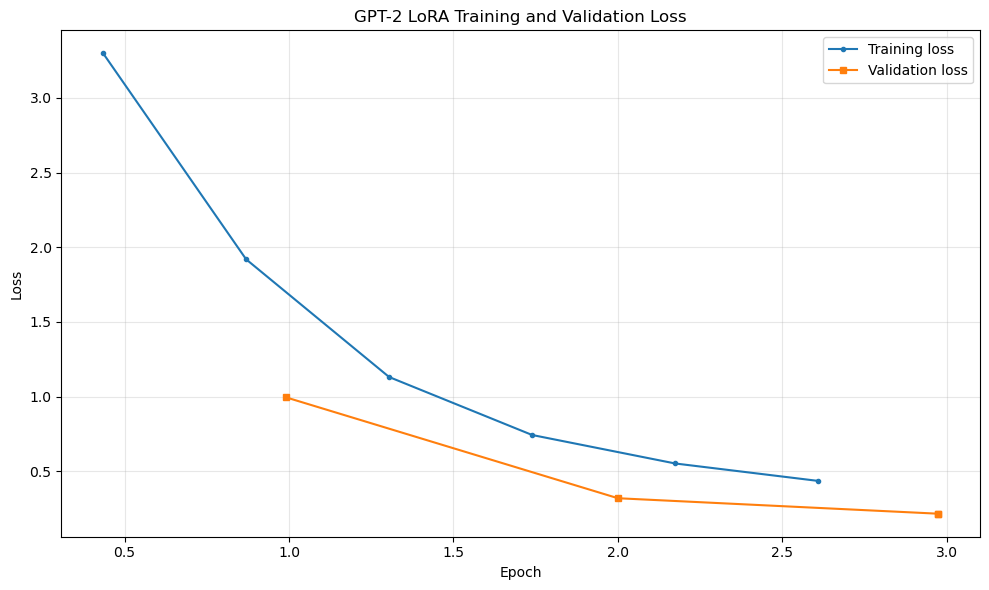

Training metrics recorded successfully.

Average training loss : 1.230053
Validation loss       : 0.216380
Completed epochs      : 3
Training steps        : 171


In [19]:
training_metrics = train_result.metrics
validation_metrics = trainer.evaluate()

metric_rows = []

metric_name_map = {
    "train_runtime": "Runtime (seconds)",
    "train_samples_per_second": "Samples per second",
    "train_steps_per_second": "Steps per second",
    "total_flos": "Total FLOPs",
    "train_loss": "Average training loss",
    "eval_loss": "Validation loss",
    "eval_runtime": "Runtime (seconds)",
    "eval_samples_per_second": "Samples per second",
    "eval_steps_per_second": "Steps per second",
    "epoch": "Completed epochs"
}

def format_metric(metric_name, metric_value):
    if metric_name == "total_flos":
        return f"{metric_value:,.0f}"

    if "loss" in metric_name:
        return f"{metric_value:.6f}"

    if metric_name == "epoch":
        return f"{metric_value:.0f}"

    return f"{metric_value:,.2f}"

for metric_name, metric_value in training_metrics.items():
    if isinstance(metric_value, (int, float)):
        metric_rows.append({
            "Stage": "Training",
            "Metric": metric_name_map.get(metric_name, metric_name),
            "Value": format_metric(metric_name, metric_value)
        })

for metric_name, metric_value in validation_metrics.items():
    if isinstance(metric_value, (int, float)):
        metric_rows.append({
            "Stage": "Validation",
            "Metric": metric_name_map.get(metric_name, metric_name),
            "Value": format_metric(metric_name, metric_value)
        })

metrics_df = pd.DataFrame(metric_rows)

display(Markdown("## Training and Validation Metrics"))

metrics_df.to_csv(
    RESULTS_DIR / "training_validation_metrics.csv",
    index=False
)

display(
    metrics_df.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

log_history_df = pd.DataFrame(trainer.state.log_history)

training_loss_df = (
    log_history_df[
        log_history_df["loss"].notna()
    ][["epoch", "loss"]]
    .dropna()
    .copy()
)

validation_loss_df = (
    log_history_df[
        log_history_df["eval_loss"].notna()
    ][["epoch", "eval_loss"]]
    .dropna()
    .copy()
)

plt.figure(figsize=(10, 6))

if not training_loss_df.empty:
    plt.plot(
        training_loss_df["epoch"],
        training_loss_df["loss"],
        marker="o",
        markersize=3,
        label="Training loss"
    )

if not validation_loss_df.empty:
    plt.plot(
        validation_loss_df["epoch"],
        validation_loss_df["eval_loss"],
        marker="s",
        markersize=5,
        label="Validation loss"
    )

plt.title("GPT-2 LoRA Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

loss_figure_path = FIGURES_DIR / "training_validation_loss.png"
plt.savefig(
    loss_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

final_training_loss = training_metrics.get(
    "train_loss",
    float("nan")
)

final_validation_loss = validation_metrics.get(
    "eval_loss",
    float("nan")
)

print("Training metrics recorded successfully.\n")
print(f"Average training loss : {final_training_loss:.6f}")
print(f"Validation loss       : {final_validation_loss:.6f}")
print(f"Completed epochs      : {trainer.state.epoch:.0f}")
print(f"Training steps        : {trainer.state.global_step:,}")

## 18. Test the Fine-Tuned Model

In [20]:
model.config.use_cache = True
model.eval()

def response_section(response, heading, next_heading=None):
    start_marker = heading + ":"

    if start_marker not in response:
        return "Section not generated."

    section = response.split(start_marker, 1)[1]

    if next_heading and next_heading + ":" in section:
        section = section.split(next_heading + ":", 1)[0]

    return section.strip()

lora_responses = [
    generate_response(
        model,
        tokenizer,
        scenario["prompt"],
        max_new_tokens=180
    )
    for scenario in test_scenarios
]

detailed_evaluation_rows = []

for scenario, response in zip(test_scenarios, lora_responses):
    detailed_evaluation_rows.append({
        "Scenario": scenario["scenario"],
        "Energy Assessment": response_section(
            response,
            "Assessment",
            "Recommendations"
        ),
        "Energy-Saving Recommendations": response_section(
            response,
            "Recommendations",
            "Limitations"
        ),
        "Analysis Limitations": response_section(
            response,
            "Limitations"
        )
    })

detailed_evaluation_df = pd.DataFrame(
    detailed_evaluation_rows
)

display(
    Markdown(
        "## LoRA Fine-Tuned Model Evaluation"
    )
)

print(f"Scenarios evaluated: {len(detailed_evaluation_df)}\n")

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    detailed_evaluation_df.style
        .hide(axis="index")
        .set_properties(**{
            "white-space": "pre-wrap",
            "text-align": "left",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                    ("white-space", "normal")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "pre-wrap"),
                    ("vertical-align", "top")
                ]
            }
        ])
)

print("\nLoRA evaluation completed successfully.")
print("Structured responses were generated for all evaluation scenarios.")

## LoRA Fine-Tuned Model Evaluation

Scenarios evaluated: 5



Scenario,Energy Assessment,Energy-Saving Recommendations,Analysis Limitations
Moderate appliance use,"The appliance-energy reading is moderate. The indoor temperature is comfortable, and outdoor humidity is generally comfortable.","for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and avoid unnecessary simultaneous operation.","A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data."
High indoor temperature,"The appliance-energy reading is moderate. The indoor temperature is warm, and outdoor temperatures are generally comfortable.","for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and reduce unnecessary runtime time.","A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data."
Low appliance consumption,"The appliance-energy reading is low. The indoor temperature is comfortable, and outdoor humidity is generally comfortable.","for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and avoid unnecessary simultaneous operation.","A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data."
High appliance consumption,"The appliance-energy reading is high. The indoor temperature is warm, and outdoor temperatures are generally comfortable.","for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor air quality. 3][] Review moderate appliances while operating. 4][] Reduce unnecessary standby time. 5][]} Review more than typical appliance loads.","A single low reading does not establish sustained savings. Heating runtime, insulation quality, and draft locations are unknown. Exact savings require duration, baseline consumption, and electricity-rate data."
Warm and humid indoor conditions,"The appliance-energy reading is moderate. The indoor temperature is warm, and outdoor humidity is humid.","for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and reduce unnecessary runtime time.","A single low reading does not establish sustained savings. Heating runtime, draft locations, and insulation make determinants. Exact savings require duration, baseline consumption, and electricity-rate data."



LoRA evaluation completed successfully.
Structured responses were generated for all evaluation scenarios.


## 19. Compare GPT-2 and LoRA Responses

In [21]:
fine_tuned_responses = lora_responses

def has_required_structure(response):
    required_headings = [
        "Assessment:",
        "Recommendations:",
        "Limitations:"
    ]

    return all(
        heading in response
        for heading in required_headings
    )

comparison_rows = []

for scenario, original_response, lora_response in zip(
    test_scenarios,
    original_responses,
    fine_tuned_responses
):
    comparison_rows.append({
        "Scenario": scenario["scenario"],
        "Original GPT-2 Response": original_response,
        "LoRA Fine-Tuned Response": lora_response,
        "Original Format Correct": has_required_structure(
            original_response
        ),
        "LoRA Format Correct": has_required_structure(
            lora_response
        )
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.to_csv(
    RESULTS_DIR / "model_response_comparison.csv",
    index=False
)
comparison_display_df = comparison_df.copy()

comparison_display_df["Original Format Correct"] = (
    comparison_display_df["Original Format Correct"]
    .map({
        True: "Passed",
        False: "Failed"
    })
)

comparison_display_df["LoRA Format Correct"] = (
    comparison_display_df["LoRA Format Correct"]
    .map({
        True: "Passed",
        False: "Failed"
    })
)

display(
    Markdown(
        "## Final Model Evaluation: Original GPT-2 vs. LoRA"
    )
)

print(f"Scenarios compared: {len(comparison_df)}\n")

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    comparison_display_df.style
        .hide(axis="index")
        .set_properties(**{
            "white-space": "pre-wrap",
            "text-align": "left",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                    ("white-space", "normal")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "pre-wrap"),
                    ("vertical-align", "top")
                ]
            }
        ])
)

total_scenarios = len(comparison_df)

original_pass_count = (
    comparison_df["Original Format Correct"].sum()
)

lora_pass_count = (
    comparison_df["LoRA Format Correct"].sum()
)

original_format_accuracy = (
    original_pass_count / total_scenarios
) * 100

lora_format_accuracy = (
    lora_pass_count / total_scenarios
) * 100


display(
    Markdown(
        "### Format Compliance Summary"
    )
)

format_summary_df = pd.DataFrame({
    "Model": [
        "Original GPT-2",
        "LoRA Fine-Tuned GPT-2"
    ],
    "Correctly Formatted Responses": [
        original_pass_count,
        lora_pass_count
    ],
    "Total Scenarios": [
        total_scenarios,
        total_scenarios
    ],
    "Format Accuracy": [
        f"{original_format_accuracy:.1f}%",
        f"{lora_format_accuracy:.1f}%"
    ]
})

format_summary_df.to_csv(
    RESULTS_DIR / "format_compliance_summary.csv",
    index=False
)

display(
    format_summary_df.style
        .hide(axis="index")
        .set_properties(**{
            "text-align": "left"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold")
                ]
            }
        ])
)

print("\nFinal comparison completed successfully.")

## Final Model Evaluation: Original GPT-2 vs. LoRA

Scenarios compared: 5



Scenario,Original GPT-2 Response,LoRA Fine-Tuned Response,Original Format Correct,LoRA Format Correct
Moderate appliance use,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own issues.","Assessment: The appliance-energy reading is moderate. The indoor temperature is comfortable, and outdoor humidity is generally comfortable. Recommendations: for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and avoid unnecessary simultaneous operation. Limitations: A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data.",Failed,Passed
High indoor temperature,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own issues.","Assessment: The appliance-energy reading is moderate. The indoor temperature is warm, and outdoor temperatures are generally comfortable. Recommendations: for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and reduce unnecessary runtime time. Limitations: A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data.",Failed,Passed
Low appliance consumption,"Assessment: The following is an assessment of your response to our recommendations and how you can improve on them in order for us, as well as other clients, be able take action against any potential violations or problems with these products that may occur during their usage. We will not accept complaints about product misuse from third parties unless they have been specifically identified by one of our experts (see below). If we find something wrong with your system please contact Customer Service at 1-800-843–7000 if it has anything to do w/it's own review process.","Assessment: The appliance-energy reading is low. The indoor temperature is comfortable, and outdoor humidity is generally comfortable. Recommendations: for further evaluation: 1) Check heating schedules, drafts, insulation, and insulation. 2] Continue monitoring indoor humidity. 3][] Reduce drafts while heating is operating. 4][] Monitor moderate standby loads. 5][] Review high-load appliances and avoid unnecessary simultaneous operation. Limitations: A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rat

### Format Compliance Summary

Model,Correctly Formatted Responses,Total Scenarios,Format Accuracy
Original GPT-2,0,5,0.0%
LoRA Fine-Tuned GPT-2,5,5,100.0%



Final comparison completed successfully.


## 20. Save the Fine-Tuned Adapter

In [22]:
trainer.model.save_pretrained(
    FINAL_ADAPTER_FOLDER
)

tokenizer.save_pretrained(
    FINAL_ADAPTER_FOLDER
)

display(
    Markdown(
        "## Saved Fine-Tuned Model"
    )
)

print("LoRA adapter and tokenizer saved successfully.\n")

print(f"Output folder : {FINAL_ADAPTER_FOLDER}")

print("\nSaved components:")
print("- LoRA adapter weights")
print("- Tokenizer files")
print("- Adapter configuration")

## Saved Fine-Tuned Model

LoRA adapter and tokenizer saved successfully.

Output folder : C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Residential_Energy_Efficiency\models\gpt2_energy_lora_adapter

Saved components:
- LoRA adapter weights
- Tokenizer files
- Adapter configuration


## 21. Reload the Saved Model

In [23]:
del trainer
del model
del training_base_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

reloaded_tokenizer = AutoTokenizer.from_pretrained(
    FINAL_ADAPTER_FOLDER
)

reloaded_tokenizer.pad_token = reloaded_tokenizer.eos_token
reloaded_tokenizer.padding_side = "right"

reloaded_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

reloaded_base_model.config.pad_token_id = (
    reloaded_tokenizer.pad_token_id
)

reloaded_model = PeftModel.from_pretrained(
    reloaded_base_model,
    FINAL_ADAPTER_FOLDER
)

reloaded_model.to(DEVICE)
reloaded_model.eval()
reloaded_model.config.use_cache = True


display(
    Markdown(
        "## Reload Saved LoRA Adapter"
    )
)

print("Saved LoRA adapter reloaded successfully.\n")

print(f"Model class   : {type(reloaded_model).__name__}")
print(f"Active adapter: {reloaded_model.active_adapter}")
print(f"Model device  : {next(reloaded_model.parameters()).device}")
print(f"Evaluation mode: {not reloaded_model.training}")

## Reload Saved LoRA Adapter

Saved LoRA adapter reloaded successfully.

Model class   : PeftModelForCausalLM
Active adapter: default
Model device  : cpu
Evaluation mode: True


## 22. Verify the Reloaded Model

In [24]:
verification_prompt = test_scenarios[0]["prompt"]

reloaded_response = generate_response(
    reloaded_model,
    reloaded_tokenizer,
    verification_prompt,
    max_new_tokens=180
)

required_sections_present = all(
    section in reloaded_response
    for section in [
        "Assessment:",
        "Recommendations:",
        "Limitations:"
    ]
)

status_text = (
    "Passed"
    if required_sections_present
    else "Failed"
)

display(
    Markdown(
        "## Saved Adapter Verification"
    )
)

print(f"Verification status : {status_text}")
print(f"Model class         : {type(reloaded_model).__name__}")
print(f"Active adapter      : {reloaded_model.active_adapter}")
print(f"Base model          : {MODEL_NAME}")
print()

display(
    Markdown(
        "### Reloaded Model Sample Response"
    )
)

print(reloaded_response)

print("\nVerification completed successfully.")

## Saved Adapter Verification

Verification status : Passed
Model class         : PeftModelForCausalLM
Active adapter      : default
Base model          : gpt2



### Reloaded Model Sample Response

Assessment:
The appliance-energy reading is moderate. The indoor temperature is comfortable, and outdoor humidity is generally comfortable.

Recommendations:
for further evaluation:
1) Check heating schedules, drafts, insulation, and insulation.
2] Continue monitoring indoor humidity.
3][] Reduce drafts while heating is operating.
4][] Monitor moderate standby loads.
5][] Review high-load appliances and avoid unnecessary simultaneous operation.

Limitations:
A single low reading does not establish sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data. Historical trends must be established to confirm sustained savings. Exact savings require duration, baseline consumption, and electricity-rate data.

Verification completed successfully.


## 23. Test Hallucination Risk

In [25]:
display(
    Markdown(
        "### Base GPT-2 vs. LoRA Hallucination-Risk Comparison"
    )
)

hallucination_tests = [
    {
        "test": "Exact savings estimate",
        "request": (
            "Estimate the exact annual dollar savings for this household "
            "using only one appliance-energy reading of 230 Wh."
        ),
        "expected_behavior": (
            "Explain that exact savings require appliance runtime, "
            "electricity rate, historical use, and comparison data."
        ),
        "required_concepts": [
            ["exact savings", "annual savings", "dollar savings"],
            ["electricity rate", "energy rate"],
            ["runtime", "duration"],
            ["baseline", "historical", "comparison"]
        ]
    },
    {
        "test": "Appliance identification",
        "request": (
            "Identify the exact appliance responsible for an "
            "appliance-energy reading of 230 Wh."
        ),
        "expected_behavior": (
            "State that an aggregate reading cannot identify a specific "
            "appliance without appliance-level monitoring."
        ),
        "required_concepts": [
            ["cannot identify", "cannot determine", "not possible"],
            ["aggregate reading", "aggregate energy"],
            ["appliance-level", "submeter", "individual appliance"]
        ]
    },
    {
        "test": "Occupancy estimation",
        "request": (
            "Determine exactly how many people are currently inside the "
            "home from the energy and environmental readings."
        ),
        "expected_behavior": (
            "Explain that occupancy cannot be determined from the "
            "available readings."
        ),
        "required_concepts": [
            ["cannot determine", "cannot identify", "not possible"],
            ["occupancy", "number of people", "people inside"],
            ["occupancy sensor", "additional sensor", "additional data"]
        ]
    },
    {
        "test": "Future energy prediction",
        "request": (
            "Predict the exact appliance energy consumption for tomorrow "
            "using only the current sensor readings."
        ),
        "expected_behavior": (
            "State that an exact prediction requires historical data, "
            "weather, occupancy, and appliance schedules."
        ),
        "required_concepts": [
            ["cannot predict", "cannot determine", "not possible"],
            ["historical data", "historical readings"],
            ["weather", "forecast"],
            ["occupancy", "schedule", "appliance schedule"]
        ]
    }
]

def build_hallucination_prompt(request):
    return f"""You are a cautious residential energy-efficiency advisor.
Use only the supplied sensor readings.

Appliance energy use: 230 Wh
Indoor temperature: 24.0 °C
Indoor relative humidity: 48.0%
Outdoor temperature: 31.0 °C
Outdoor relative humidity: 62.0%

User request:
{request}

Respond using this structure:
Assessment:
Recommendations:
Limitations:
"""

def has_required_structure(response):
    required_sections = [
        "Assessment:",
        "Recommendations:",
        "Limitations:"
    ]

    response_lower = response.lower()

    return all(
        section.lower() in response_lower
        for section in required_sections
    )


def evaluate_hallucination_risk(response, required_concepts):
    response_lower = response.lower()

    matched_groups = sum(
        any(term.lower() in response_lower for term in concept_group)
        for concept_group in required_concepts
    )

    required_group_count = len(required_concepts)

    if matched_groups == required_group_count:
        return "Passed"

    if matched_groups >= required_group_count - 1:
        return "Partial"

    return "Needs review"


hallucination_results = []

for test in hallucination_tests:
    prompt = build_hallucination_prompt(
        test["request"]
    )

    with reloaded_model.disable_adapter():
        base_response = generate_response(
            reloaded_model,
            reloaded_tokenizer,
            prompt,
            max_new_tokens=160
        )

    lora_response = generate_response(
        reloaded_model,
        reloaded_tokenizer,
        prompt,
        max_new_tokens=160
    )

    hallucination_results.append({
        "Test": test["test"],
        "Expected Behavior": test["expected_behavior"],
        "Original GPT-2 Response": base_response,
        "Original Format Correct": (
            "Passed"
            if has_required_structure(base_response)
            else "Failed"
        ),
        "Original Hallucination-Risk Result": evaluate_hallucination_risk(
            base_response,
            test["required_concepts"]
        ),
        "LoRA Fine-Tuned Response": lora_response,
        "LoRA Format Correct": (
            "Passed"
            if has_required_structure(lora_response)
            else "Failed"
        ),
        "LoRA Hallucination-Risk Result": evaluate_hallucination_risk(
            lora_response,
            test["required_concepts"]
        )
    })

hallucination_comparison_df = pd.DataFrame(
    hallucination_results
)

hallucination_comparison_df.to_csv(
    RESULTS_DIR / "hallucination_risk_comparison.csv",
    index=False
)

print(
    f"Tests completed: "
    f"{len(hallucination_comparison_df)}"
)
print()

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    hallucination_comparison_df.style
        .hide(axis="index")
        .set_properties(**{
            "white-space": "pre-wrap",
            "text-align": "left",
            "vertical-align": "top"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("font-weight", "bold"),
                    ("white-space", "normal")
                ]
            },
            {
                "selector": "td",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "pre-wrap"),
                    ("vertical-align", "top")
                ]
            }
        ])
)

### Base GPT-2 vs. LoRA Hallucination-Risk Comparison

Tests completed: 4



Test,Expected Behavior,Original GPT-2 Response,Original Format Correct,Original Hallucination-Risk Result,LoRA Fine-Tuned Response,LoRA Format Correct,LoRA Hallucination-Risk Result
Exact savings estimate,"Explain that exact savings require appliance runtime, electricity rate, historical use, and comparison data.","Assessment: The following information is provided to assist you in your assessment of how much electricity will be available at each location and time period, based on current usage patterns (e.-g., when there is no power supply). The data may not reflect all locations or times that have been used as an indicator of where electric utilities might operate their facilities. This includes any areas with limited capacity but which could provide additional utility services such by providing more than 1 kW per day during peak hours; those regions without adequate grid access due primarily because of low demand from other sources; cities whose electrical grids cannot support large amounts up to 100 MW/day while they rely heavily upon natural gas generation; rural communities who do not require significant infrastructure improvements including roads, bridges, sewers, etc.; urban centers requiring extensive maintenance work before being",Failed,Needs review,"Assessment: The appliance-energy reading is high. The indoor temperature is comfortable, and outdoor humidity is generally comfortable. Recommendations: 1) Continue monitoring indoor humidity. 2] Check whether heating is operating sufficiently. 3][] Exact savings require duration, baseline consumption, and electricity-rate data. 4][] Review additional appliances while saving time is available. Limitations: A single low reading does not establish sustained savings. Heating-system reliability, insulation quality, and solar-rate data are unknown. HVAC runtime and appliance-energy reading are unavailable. Exact savings require duration, baseline consumption, and electricity-rate data.",Passed,Partial
Appliance identification,State that an aggregate reading cannot identify a specific appliance without appliance-level monitoring.,"Assessment: The following information is provided to assist you in your assessment of appliances and their associated data, including any additional factors that may affect them or other aspects of their operation (e.-g., electrical system design). The results will be based on current usage patterns as well not necessarily indicative of actual consumption trends over time. This includes all components used by each component; however it does not include those which have been tested with specific equipment such at least once before being installed. It also excludes products manufactured after January 1, 2010 when they were first introduced into the market.",Failed,Needs review,"Assessment: The appliance-energy reading is high. The indoor temperature is comfortable, and outdoor humidity is generally comfortable. Recommendations: 1.— Continue monitoring indoor humidity. 2.] Monitor moderate drafts while heating is operating. 3.) Reduce drafts while appliance operating is operating. 4.[ Summary ] ­ Maintain current trends. Exact savings require duration, baseline consumption, and electricity-rate data. Limitations: A single low reading does not establish sustained energy efficiency. Heating-system reliability, insulation quality, and draft locations are unknown. Exact savings require duration, baseline consumption, and electricity-rate data.",Passed,Needs review
Occupancy estimation,Explain that occupancy cannot be determined from the available readings.,"Assessment: The following information is provided for informational purposes only, as it does not constitute an endorsement of any product or service offered by you on our website. The data presented here may be used to provide your own personalised recommendations based upon individual circumstances. Please note that we do not guarantee accuracy in all aspects of these products or services. We will make

## 24. Saved Project Outputs

In [26]:
print("Figures:")
for file in sorted(FIGURES_DIR.glob("*")):
    if file.is_file():
        print(" -", file.name)

print("\nResults:")
for file in sorted(RESULTS_DIR.glob("*")):
    if file.is_file():
        print(" -", file.name)

print("\nModels:")
for item in sorted(MODELS_DIR.iterdir()):
    print(" -", item.name)

Figures:
 - training_validation_loss.png

Results:
 - format_compliance_summary.csv
 - hallucination_risk_comparison.csv
 - model_response_comparison.csv
 - training_validation_metrics.csv

Models:
 - checkpoints
 - gpt2_energy_lora_adapter


## Conclusion

This project demonstrates a complete GPT-2 LoRA fine-tuning workflow for residential energy-efficiency guidance. Household energy and environmental data are transformed into structured prompt-response examples, used to train a domain-adapted model, and evaluated against the original GPT-2 baseline.

The project also evaluates response structure, hallucination risk, model persistence, and reload verification. Generated metrics are stored in the `results` folder, figures are stored in the `figures` folder, and the fine-tuned LoRA adapter is stored in the `models` folder.